# Phase 4: Lựa Chọn Đặc Trưng Tối Ưu (Feature Selection Pipeline)
## CICIoT2023 Network Intrusion Detection
### Đề tài Tốt nghiệp: Hệ thống phát hiện tấn công mạng IoT dựa trên XAI

---

### 🎯 Mục tiêu & Đóng góp Phương pháp luận của Phase 4
1. **Triệt tiêu Đặc trưng Hằng số / Gần hằng số (Variance Threshold Filtering)**:
   - Loại bỏ các đặc trưng có phương sai $\le 0.001$, hầu như không mang thông tin phân biệt (quasi-constant features).
2. **Cắt tỉa Đa cộng tuyến Tuyến tính (Collinearity Pruning)**:
   - Phân tích ma trận tương quan Pearson, phát hiện và cắt tỉa có chọn lọc các cặp đặc trưng trùng lặp mạnh ($|r| \ge 0.90$) bằng phương pháp tham lam (greedy mean correlation pruning).
3. **Độ quan trọng Đồng thuận Dựa trên Mô hình Cây (Consensus Feature Importance)**:
   - Kết hợp hai trường phái thuật toán cây mạnh nhất:
     - **Random Forest**: Đánh giá Mean Decrease in Impurity (Gini/MDI).
     - **XGBoost / LightGBM**: Đánh giá Gradient Split Gain Importance.
     - $\text{Consensus}(f) = \frac{\text{Norm}(I_{\text{RF}}(f)) + \text{Norm}(I_{\text{GBDT}}(f))}{2}$.
4. **Tối ưu hóa Chiều Dữ liệu theo Định luật Pareto (Top N Selection)**:
   - Chọn lọc Top 25 đặc trưng then chốt (chiếm $\ge 95\%$ tổng mức độ quan trọng tích lũy).
   - Giảm dung lượng và thời gian huấn luyện ở Phase 5 từ 2-3 lần trong khi bảo toàn năng lực phân loại.
5. **Khảo sát Không gian Tiềm ẩn PCA (PCA Dimensionality Reduction Scree Plot)**:
   - Đánh giá số chiều cần thiết để giải thích 80%, 90%, 95%, 99% tổng phương sai không gian dữ liệu.
6. **Đồng bộ hóa Không gian Đặc trưng Giữa Train và Test (Feature Space Alignment)**:
   - Tự động áp dụng cùng tập đặc trưng đã chọn lọc lên cả tập huấn luyện (`X_train_selected.pkl`) và tập kiểm thử (`X_test_selected.pkl`), ngăn chặn hoàn toàn lỗi lệch số chiều ở Phase 5 & 6.

## Cấu hình Môi trường Google Colab & Điều hướng Lưu trữ trực tiếp trên Drive
> 🎯 **Lưu trữ trực tiếp**: Tự động mount Google Drive và chuyển working directory về `/content/drive/MyDrive/do_an`. Mọi file (`data/`, `models/`, `plots/`) sinh ra sẽ nằm an toàn trên Drive của bạn.

In [1]:
# ==============================================================================
# Cell 0: Cấu hình Môi trường Google Colab & Điều hướng Lưu trữ trực tiếp trên Drive
# ==============================================================================
import os
import sys

# Kiểm tra nếu đang chạy trên Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    
    # 🎯 ĐIỀU HƯỚNG WORKING DIRECTORY TRỰC TIẾP VÀO THƯ MỤC GOOGLE DRIVE
    DRIVE_DIR = "/content/drive/MyDrive/do_an"
    os.makedirs(DRIVE_DIR, exist_ok=True)
    os.chdir(DRIVE_DIR)
    
    # Tạo sẵn các thư mục con lưu trữ trực tiếp trên Google Drive
    os.makedirs("data", exist_ok=True)
    os.makedirs("models", exist_ok=True)
    os.makedirs("plots", exist_ok=True)
    
    print(f"🚀 [Google Colab] Đã chuyển working directory trực tiếp về: {os.getcwd()}")
    print("📁 Tất cả kết quả (data/, models/, plots/) sẽ được ghi TRỰC TIẾP lên Google Drive!")
else:
    os.makedirs("data", exist_ok=True)
    os.makedirs("models", exist_ok=True)
    os.makedirs("plots", exist_ok=True)
    print(f"💻 [Local] Đang chạy trên máy cục bộ. Working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 [Google Colab] Đã chuyển working directory trực tiếp về: /content/drive/MyDrive/do_an
📁 Tất cả kết quả (data/, models/, plots/) sẽ được ghi TRỰC TIẾP lên Google Drive!


## Cell 1: Khởi tạo Thư viện & Nạp Dữ liệu Tiền xử lý (Phase 2 / Phase 3)
Hệ thống sẽ tự động ưu tiên nạp tập dữ liệu cân bằng từ Phase 3 (`data/X_train_balanced.pkl`) để đảm bảo các lớp tấn công thiểu số (Malware, Web) được đại diện đầy đủ khi đánh giá tầm quan trọng của đặc trưng.

In [2]:
# ==============================================================================
# Cell 1: Import Libraries & Nạp Dữ liệu
# ==============================================================================
import os
import gc
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Kiểm tra Gradient Boosting frameworks
XGB_AVAILABLE = False
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print(f"XGBoost: Available (v{xgb.__version__})")
except ImportError:
    print("XGBoost: Not installed")

LGBM_AVAILABLE = False
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
    print(f"LightGBM: Available (v{lgb.__version__})")
except ImportError:
    print("LightGBM: Not installed")

warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Tìm kiếm và nạp dữ liệu (Ưu tiên Phase 3 Balanced Set)
x_paths = ['data/X_train_balanced.pkl', 'X_train_balanced.pkl', 'data/X_train.pkl', 'X_train.pkl']
y_paths = ['data/y_train_balanced.pkl', 'y_train_balanced.pkl', 'data/y_train.pkl', 'y_train.pkl']

X_train = None
for xp in x_paths:
    if os.path.exists(xp):
        print(f"Nạp ma trận đặc trưng từ: {xp}")
        X_train = joblib.load(xp)
        break
if X_train is None:
    raise FileNotFoundError("Không tìm thấy X_train.pkl hoặc X_train_balanced.pkl! Hãy chạy Phase 2 hoặc 3 trước.")

y_dict = None
for yp in y_paths:
    if os.path.exists(yp):
        print(f"Nạp nhãn mục tiêu từ:      {yp}")
        y_dict = joblib.load(yp)
        break

# Đảm bảo DataFrame
preprocessor = joblib.load('models/preprocessor.joblib') if os.path.exists('models/preprocessor.joblib') else None
if not isinstance(X_train, pd.DataFrame):
    feat_names = preprocessor.get('feature_names', [f'feat_{i}' for i in range(X_train.shape[1])]) if preprocessor else [f'feat_{i}' for i in range(X_train.shape[1])]
    X_train = pd.DataFrame(X_train, columns=feat_names, dtype='float32')

# Phân giải nhãn mục tiêu thông minh
if isinstance(y_dict, dict):
    if 'target_encoded' in y_dict:
        tier_name = y_dict.get('target_tier', 'label')
        y_target = y_dict['target_encoded']
        print(f"-> Sử dụng nhãn Phase 3 cân bằng: '{tier_name}' ({len(np.unique(y_target))} lớp)")
    elif 'label_encoded' in y_dict:
        y_target = y_dict['label_encoded']
        print(f"-> Sử dụng nhãn Phase 2: 'label_encoded' ({len(np.unique(y_target))} lớp chi tiết)")
    elif 'category_encoded' in y_dict:
        y_target = y_dict['category_encoded']
        print(f"-> Sử dụng nhãn Phase 2: 'category_encoded' ({len(np.unique(y_target))} nhóm tấn công)")
    else:
        first_k = list(y_dict.keys())[0]
        y_target = y_dict[first_k]
else:
    y_target = np.array(y_dict)

print(f"\nKích thước tập huấn luyện: {X_train.shape[0]:,} dòng x {X_train.shape[1]} đặc trưng")
print(f"Dung lượng bộ nhớ RAM:     {X_train.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

XGBoost: Available (v3.4.1)
LightGBM: Available (v4.6.0)
Nạp ma trận đặc trưng từ: data/X_train_balanced.pkl
Nạp nhãn mục tiêu từ:      data/y_train_balanced.pkl
-> Sử dụng nhãn Phase 3 cân bằng: 'label' (34 lớp)

Kích thước tập huấn luyện: 267,062 dòng x 58 đặc trưng
Dung lượng bộ nhớ RAM:     59.09 MB


## Task 4.1: Lọc Bỏ Đặc Trưng Gần Hằng Số (Variance Threshold Filtering)
- Thiết lập ngưỡng phương sai tối thiểu $\tau = 0.001$.
- Các đặc trưng có $\text{Var}(X_j) \le \tau$ (ví dụ các cờ giao thức luôn bằng 0) sẽ bị loại bỏ vì không có thông tin phân biệt.

In [3]:
# ==============================================================================
# Cell 2: Task 4.1 - Variance Threshold Filtering
# ==============================================================================
VAR_THRESHOLD = 0.001

print("=" * 75)
print(f"TASK 4.1: LỌC THEO PHƯƠNG SAI ĐẶC TRƯNG (Ngưỡng tau = {VAR_THRESHOLD})")
print("=" * 75)

variances = X_train.var(axis=0)
var_df = pd.DataFrame({
    'feature': X_train.columns,
    'variance': variances.values
}).sort_values('variance', ascending=True).reset_index(drop=True)

low_var_features = var_df[var_df['variance'] <= VAR_THRESHOLD]['feature'].tolist()
features_after_var = var_df[var_df['variance'] > VAR_THRESHOLD]['feature'].tolist()

print(f"Tổng số đặc trưng ban đầu:           {len(X_train.columns)}")
print(f"Đặc trưng có phương sai thấp (<= {VAR_THRESHOLD}): {len(low_var_features)}")
print(f"Đặc trưng giữ lại (> {VAR_THRESHOLD}):            {len(features_after_var)}")

if low_var_features:
    print("\nDanh sách các đặc trưng có phương sai quá thấp (bị loại bỏ):")
    for f in low_var_features:
        print(f"  - {f:30s} (var = {variances[f]:.8f})")
else:
    print("\n-> Tất cả các đặc trưng đều có phương sai đạt chuẩn!")

TASK 4.1: LỌC THEO PHƯƠNG SAI ĐẶC TRƯNG (Ngưỡng tau = 0.001)
Tổng số đặc trưng ban đầu:           58
Đặc trưng có phương sai thấp (<= 0.001): 6
Đặc trưng giữ lại (> 0.001):            52

Danh sách các đặc trưng có phương sai quá thấp (bị loại bỏ):
  - ece_flag_number                (var = 0.00000000)
  - cwr_flag_number                (var = 0.00000000)
  - DHCP                           (var = 0.00000000)
  - SMTP                           (var = 0.00000000)
  - drate_ratio                    (var = 0.00000002)
  - Drate                          (var = 0.00000010)


## Trực quan hóa Phân phối Phương sai (Plot 09)

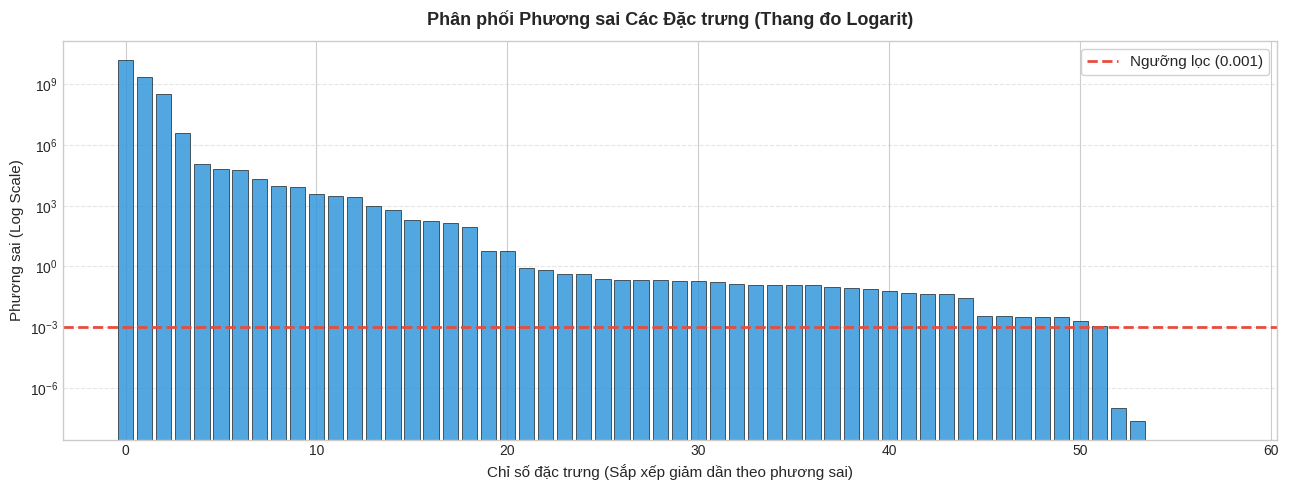

Đã lưu biểu đồ: plots/09_variance_distribution.png


In [4]:
# ==============================================================================
# Cell 3: Plot 09 - Phân phối Phương sai Đặc trưng
# ==============================================================================
fig, ax = plt.subplots(figsize=(13, 5))
sorted_v = var_df.sort_values('variance', ascending=False).reset_index(drop=True)

ax.bar(range(len(sorted_v)), sorted_v['variance'], color='#3498db', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(VAR_THRESHOLD, color='#e74c3c', linestyle='--', linewidth=2, label=f'Ngưỡng lọc ({VAR_THRESHOLD})')
ax.set_yscale('log')
ax.set_title('Phân phối Phương sai Các Đặc trưng (Thang đo Logarit)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Chỉ số đặc trưng (Sắp xếp giảm dần theo phương sai)', fontsize=11)
ax.set_ylabel('Phương sai (Log Scale)', fontsize=11)
ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.savefig('plots/09_variance_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ: plots/09_variance_distribution.png")

## Task 4.2: Phân Tích Tương Quan & Cắt Tỉa Đa Cộng Tuyến (Collinearity Pruning)
- Phát hiện các cặp đặc trưng có hệ số tương quan Pearson $|r| \ge 0.90$.
- Áp dụng **Greedy Mean Correlation Pruning**: Giữ lại đặc trưng có mức tương quan trung bình thấp hơn với toàn bộ các đặc trưng khác, loại bỏ đặc trưng bị dư thừa.

In [5]:
# ==============================================================================
# Cell 4: Task 4.2 - Correlation Analysis & Collinearity Pruning
# ==============================================================================
CORR_THRESHOLD = 0.90
SAMPLE_CORR = min(100000, len(X_train))

print("=" * 75)
print(f"TASK 4.2: PHÂN TÍCH ĐA CỘNG TUYẾN (Ngưỡng |r| >= {CORR_THRESHOLD})")
print("=" * 75)

X_corr_sub = X_train[features_after_var].sample(n=SAMPLE_CORR, random_state=42)
corr_matrix = X_corr_sub.corr(method='pearson')
abs_corr = corr_matrix.abs()

# Trích xuất các cặp tam giác trên
upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
collinear_pairs = []

for col in upper_tri.columns:
    high_corr = upper_tri[col][upper_tri[col] >= CORR_THRESHOLD]
    for row, r_val in high_corr.items():
        collinear_pairs.append({
            'feature_1': row,
            'feature_2': col,
            'correlation': r_val
        })

print(f"Phát hiện {len(collinear_pairs)} cặp đặc trưng đa cộng tuyến mạnh (|r| >= {CORR_THRESHOLD}):")
features_to_drop = set()
mean_corr = abs_corr.mean()

for pair in collinear_pairs:
    f1, f2 = pair['feature_1'], pair['feature_2']
    if f1 not in features_to_drop and f2 not in features_to_drop:
        drop_f = f1 if mean_corr[f1] >= mean_corr[f2] else f2
        features_to_drop.add(drop_f)
        print(f"  [Collinear] {f1:25s} <-> {f2:25s} (r = {pair['correlation']:.4f}) -> Loại bỏ '{drop_f}'")

dropped_corr_features = sorted(list(features_to_drop))
features_after_corr = [f for f in features_after_var if f not in features_to_drop]

print(f"\nTổng số đặc trưng bị loại do đa cộng tuyến: {len(dropped_corr_features)}")
print(f"Số đặc trưng còn lại sau khi cắt tỉa:       {len(features_after_corr)}")

TASK 4.2: PHÂN TÍCH ĐA CỘNG TUYẾN (Ngưỡng |r| >= 0.9)
Phát hiện 13 cặp đặc trưng đa cộng tuyến mạnh (|r| >= 0.9):
  [Collinear] IPv                       <-> LLC                       (r = 1.0000) -> Loại bỏ 'IPv'
  [Collinear] SSH                       <-> remote_access             (r = 1.0000) -> Loại bỏ 'SSH'
  [Collinear] HTTPS                     <-> is_encrypted              (r = 0.9847) -> Loại bỏ 'is_encrypted'
  [Collinear] Srate                     <-> Rate                      (r = 1.0000) -> Loại bỏ 'Srate'
  [Collinear] Tot size                  <-> Tot sum                   (r = 0.9363) -> Loại bỏ 'Tot sum'
  [Collinear] Tot size                  <-> Magnitue                  (r = 0.9373) -> Loại bỏ 'Magnitue'
  [Collinear] Number                    <-> Weight                    (r = 0.9999) -> Loại bỏ 'Number'
  [Collinear] Max                       <-> Std                       (r = 0.9554) -> Loại bỏ 'Max'
  [Collinear] Std                       <-> Radius             

## Trực quan hóa Ma trận Tương quan (Plot 10)

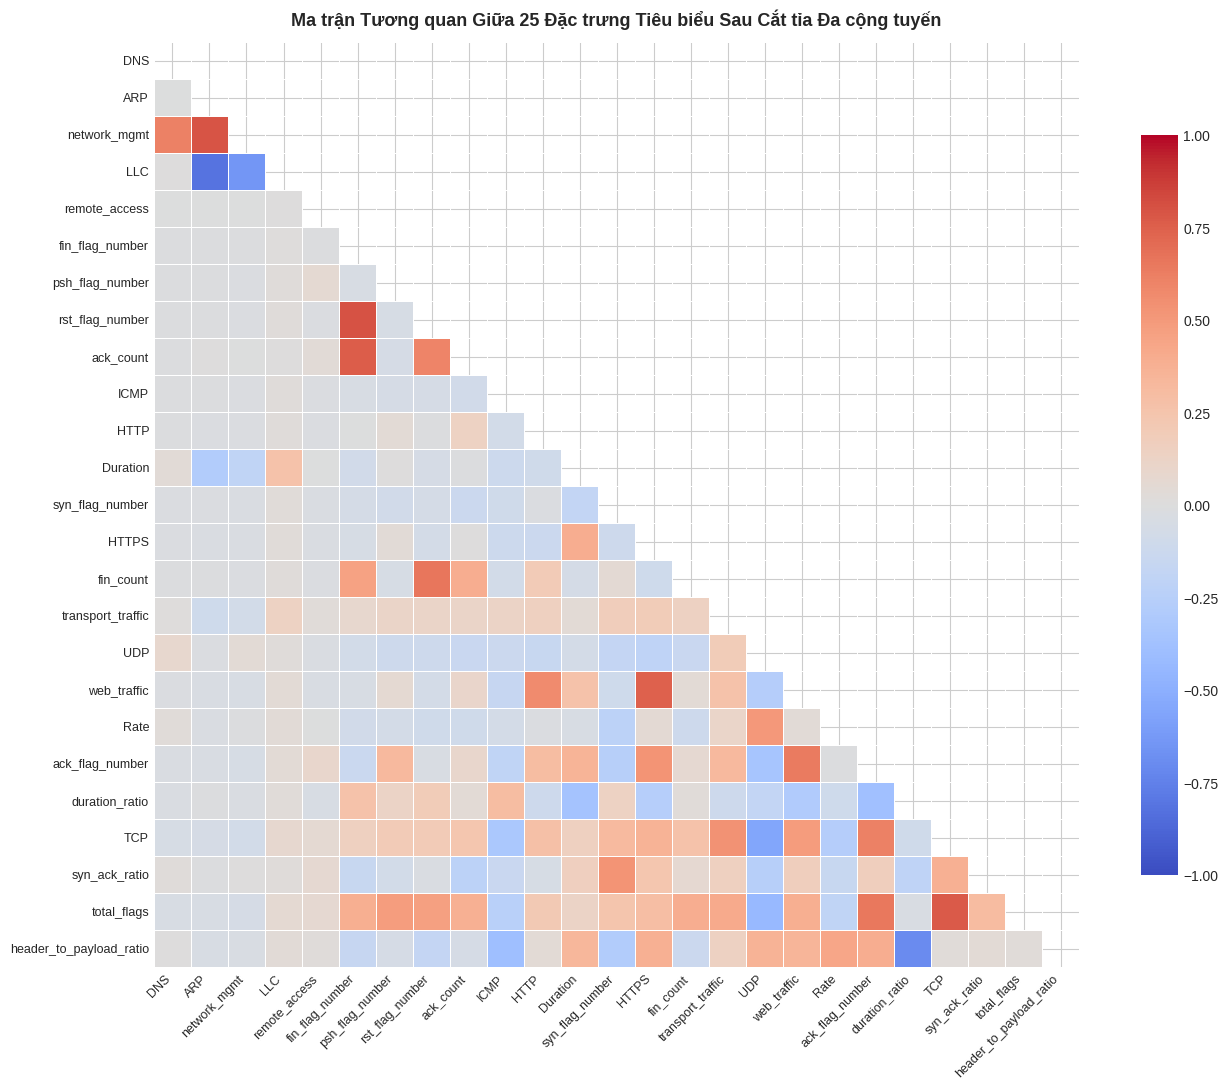

Đã lưu biểu đồ: plots/10_correlation_clustermap.png


In [6]:
# ==============================================================================
# Cell 5: Plot 10 - Ma trận Nhiệt Tương quan (Correlation Heatmap)
# ==============================================================================
fig, ax = plt.subplots(figsize=(14, 11))
sample_cols = features_after_corr[:25]   # Lấy 25 đặc trưng tiêu biểu để trực quan sắc nét
sub_corr = corr_matrix.loc[sample_cols, sample_cols]
mask = np.triu(np.ones_like(sub_corr, dtype=bool))

sns.heatmap(sub_corr, mask=mask, cmap='coolwarm', vmin=-1.0, vmax=1.0, center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Ma trận Tương quan Giữa 25 Đặc trưng Tiêu biểu Sau Cắt tỉa Đa cộng tuyến', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('plots/10_correlation_clustermap.png', dpi=200, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ: plots/10_correlation_clustermap.png")

## Task 4.3: Đánh Giá Độ Quan Trọng Bằng Ensemble Tree Models (Consensus Importance)
- Huấn luyện song song **Random Forest Classifier** (đo Gini/MDI) và **XGBoost / LightGBM** (đo Gradient Gain).
- Tính điểm đồng thuận chuẩn hóa: $\text{Consensus}(f) = \frac{\text{Norm}(I_{\text{RF}}) + \text{Norm}(I_{\text{GBDT}})}{2}$.

In [7]:
# ==============================================================================
# Cell 6: Task 4.3 - Model-based Feature Importance
# ==============================================================================
SAMPLE_IMP = min(100000, len(X_train))

print("=" * 75)
print("TASK 4.3: ĐÁNH GIÁ ĐỘ QUAN TRỌNG ĐẶC TRƯNG (CONSENSUS FEATURE IMPORTANCE)")
print("=" * 75)

X_filtered = X_train[features_after_corr]
try:
    X_sample, _, y_sample, _ = train_test_split(
        X_filtered, y_target, train_size=SAMPLE_IMP, stratify=y_target, random_state=42
    )
except Exception:
    idx = np.random.RandomState(42).choice(len(X_filtered), size=SAMPLE_IMP, replace=False)
    X_sample = X_filtered.iloc[idx]
    y_sample = y_target[idx] if isinstance(y_target, np.ndarray) else y_target.iloc[idx]

print(f"Huấn luyện trên tập phân tầng: {X_sample.shape[0]:,} dòng x {X_sample.shape[1]} đặc trưng")

# 1. Random Forest
print("\n[1/2] Đang huấn luyện Random Forest (n_estimators=100, max_depth=14)...")
rf = RandomForestClassifier(n_estimators=100, max_depth=14, min_samples_split=10,
                            max_features='sqrt', n_jobs=-1, random_state=42)
rf.fit(X_sample, y_sample)
rf_imp = rf.feature_importances_
rf_norm = rf_imp / rf_imp.sum()
print("Hoàn tất huấn luyện Random Forest.")

# 2. XGBoost hoặc LightGBM
model_name = "Gradient Boosting"
if XGB_AVAILABLE:
    print("[2/2] Đang huấn luyện XGBoost Classifier (n_estimators=100, max_depth=6)...")
    model_name = "XGBoost"
    sec_clf = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                random_state=42, eval_metric='mlogloss', tree_method='hist')
    sec_clf.fit(X_sample, y_sample)
    sec_imp = sec_clf.feature_importances_
elif LGBM_AVAILABLE:
    print("[2/2] Đang huấn luyện LightGBM Classifier (n_estimators=100, max_depth=6)...")
    model_name = "LightGBM"
    sec_clf = lgb.LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                 n_jobs=-1, random_state=42, verbosity=-1)
    sec_clf.fit(X_sample, y_sample)
    sec_imp = sec_clf.feature_importances_
else:
    print("[2/2] Đang huấn luyện ExtraTreesClassifier thay thế...")
    model_name = "ExtraTrees"
    sec_clf = ExtraTreesClassifier(n_estimators=100, max_depth=14, max_features='sqrt',
                                   n_jobs=-1, random_state=42)
    sec_clf.fit(X_sample, y_sample)
    sec_imp = sec_clf.feature_importances_

sec_norm = sec_imp / sec_imp.sum()
print(f"Hoàn tất huấn luyện {model_name}.")

# 3. Tính điểm đồng thuận (Consensus Importance)
consensus_score = (rf_norm + sec_norm) / 2.0

importance_df = pd.DataFrame({
    'feature': features_after_corr,
    'rf_importance': rf_norm,
    f'{model_name.lower()}_importance': sec_norm,
    'consensus_importance': consensus_score
}).sort_values('consensus_importance', ascending=False).reset_index(drop=True)

importance_df['rank'] = range(1, len(importance_df) + 1)
importance_df['cumulative_importance'] = importance_df['consensus_importance'].cumsum()

print("\nBảng Xếp Hạng Top 15 Đặc Trưng Dự Đoán Tốt Nhất:")
for idx, row in importance_df.head(15).iterrows():
    print(f"  #{row['rank']:2d}: {row['feature']:28s} Score: {row['consensus_importance']*100:5.2f}% (Tích lũy: {row['cumulative_importance']*100:5.2f}%)")

TASK 4.3: ĐÁNH GIÁ ĐỘ QUAN TRỌNG ĐẶC TRƯNG (CONSENSUS FEATURE IMPORTANCE)
Huấn luyện trên tập phân tầng: 100,000 dòng x 42 đặc trưng

[1/2] Đang huấn luyện Random Forest (n_estimators=100, max_depth=14)...
Hoàn tất huấn luyện Random Forest.
[2/2] Đang huấn luyện XGBoost Classifier (n_estimators=100, max_depth=6)...
Hoàn tất huấn luyện XGBoost.

Bảng Xếp Hạng Top 15 Đặc Trưng Dự Đoán Tốt Nhất:
  # 1: fin_flag_number              Score: 18.81% (Tích lũy: 18.81%)
  # 2: IAT                          Score: 10.61% (Tích lũy: 29.41%)
  # 3: ICMP                         Score:  6.73% (Tích lũy: 36.14%)
  # 4: syn_flag_number              Score:  4.73% (Tích lũy: 40.87%)
  # 5: AVG                          Score:  4.11% (Tích lũy: 44.98%)
  # 6: Tot size                     Score:  3.91% (Tích lũy: 48.88%)
  # 7: psh_flag_number              Score:  3.84% (Tích lũy: 52.72%)
  # 8: Protocol Type                Score:  3.39% (Tích lũy: 56.11%)
  # 9: Header_Length                Score:  2.88% (T

## Trực quan hóa So sánh Độ Quan trọng (Plot 11)

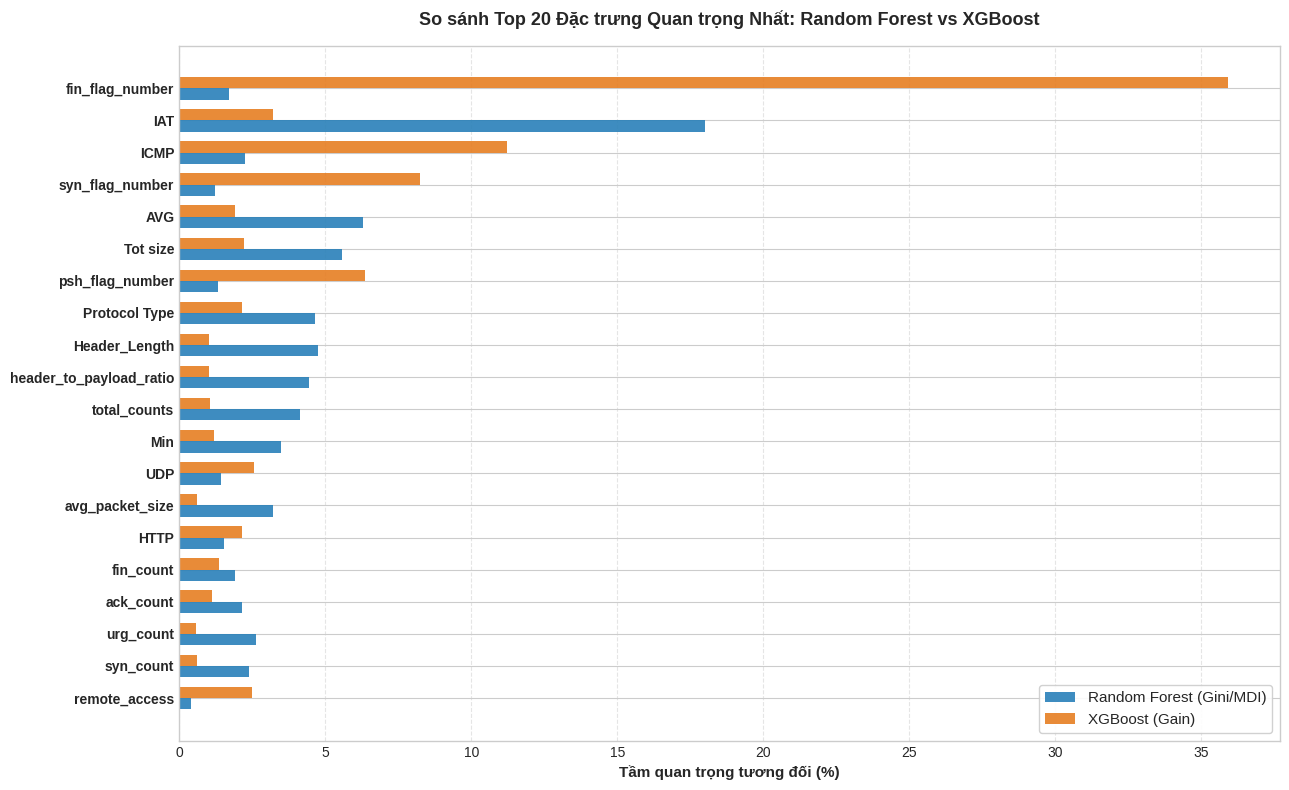

Đã lưu biểu đồ: plots/11_feature_importance.png


In [8]:
# ==============================================================================
# Cell 7: Plot 11 - So sánh Top 20 Đặc trưng Quan trọng: RF vs GBDT
# ==============================================================================
top_plot = importance_df.head(20).sort_values('consensus_importance', ascending=True)
y_pos = np.arange(len(top_plot))
height = 0.35

fig, ax = plt.subplots(figsize=(13, 8))
sec_col = f'{model_name.lower()}_importance'
ax.barh(y_pos - height/2, top_plot['rf_importance'] * 100, height, label='Random Forest (Gini/MDI)', color='#2980b9', alpha=0.9)
ax.barh(y_pos + height/2, top_plot[sec_col] * 100, height, label=f'{model_name} (Gain)', color='#e67e22', alpha=0.9)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_plot['feature'], fontsize=10, fontweight='bold')
ax.set_xlabel('Tầm quan trọng tương đối (%)', fontsize=11, fontweight='bold')
ax.set_title(f'So sánh Top 20 Đặc trưng Quan trọng Nhất: Random Forest vs {model_name}', fontsize=13, fontweight='bold', pad=15)
ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.savefig('plots/11_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ: plots/11_feature_importance.png")

## Task 4.4: Lựa Chọn Top N Đặc Trưng Tối Ưu (Pareto Cutoff)
- Lựa chọn **Top 25 đặc trưng hàng đầu** (đạt ngưỡng tích lũy $\ge 95\%$ tổng mức độ quan trọng).
- Xuất tập dữ liệu rút gọn `data/X_train_selected.pkl` và tự động rút gọn cả tập `data/X_test_selected.pkl` (nếu có).

In [9]:
# ==============================================================================
# Cell 8: Task 4.4 - Select Top N Features & Xuất Dữ liệu Rút gọn
# ==============================================================================
TOP_K = 25
CUMULATIVE_CUTOFF = 0.95

print("=" * 75)
print(f"TASK 4.4: LỰA CHỌN TOP {TOP_K} ĐẶC TRƯNG TIÊU BIỂU (Ngưỡng tích lũy: {CUMULATIVE_CUTOFF*100:.0f}%)")
print("=" * 75)

selected_features = importance_df.head(TOP_K)['feature'].tolist()
captured_importance = importance_df[importance_df['feature'].isin(selected_features)]['consensus_importance'].sum()
dropped_total_features = [f for f in X_train.columns if f not in selected_features]

print(f"Số lượng đặc trưng được chọn:             {len(selected_features)}")
print(f"Tổng tỉ lệ độ quan trọng tích lũy giữ lại: {captured_importance * 100:.2f}%")
print(f"Số lượng đặc trưng được cắt giảm:          {len(dropped_total_features)}")

X_train_selected = X_train[selected_features].copy()
print(f"\nKích thước tập huấn luyện rút gọn: {X_train_selected.shape[0]:,} dòng x {X_train_selected.shape[1]} đặc trưng")
print(f"Dung lượng RAM mới:               {X_train_selected.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

TASK 4.4: LỰA CHỌN TOP 25 ĐẶC TRƯNG TIÊU BIỂU (Ngưỡng tích lũy: 95%)
Số lượng đặc trưng được chọn:             25
Tổng tỉ lệ độ quan trọng tích lũy giữ lại: 86.81%
Số lượng đặc trưng được cắt giảm:          33

Kích thước tập huấn luyện rút gọn: 267,062 dòng x 25 đặc trưng
Dung lượng RAM mới:               25.47 MB


## Trực quan hóa Biểu đồ Pareto (Plot 12)

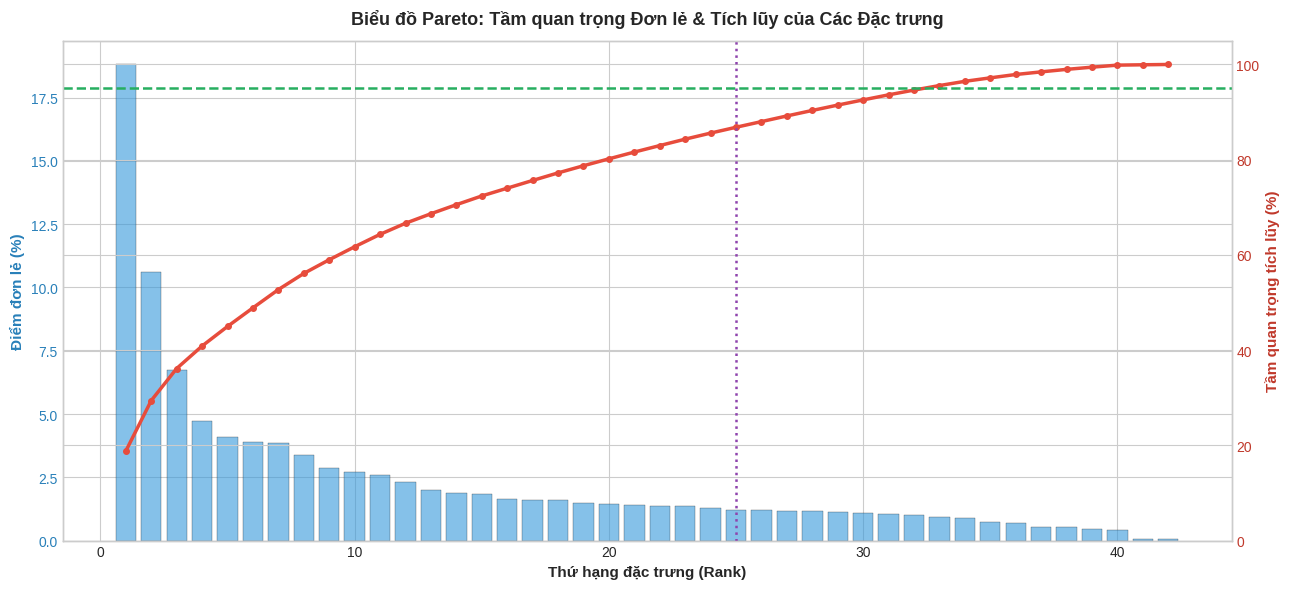

Đã lưu biểu đồ: plots/12_cumulative_importance.png


In [10]:
# ==============================================================================
# Cell 9: Plot 12 - Biểu đồ Pareto Tầm quan trọng Đơn lẻ & Tích lũy
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(13, 6))
x_ranks = importance_df['rank'].values
y_cum = importance_df['cumulative_importance'].values * 100
y_ind = importance_df['consensus_importance'].values * 100

ax1.bar(x_ranks, y_ind, color='#3498db', alpha=0.6, label='Tầm quan trọng đơn lẻ (%)', edgecolor='black', linewidth=0.3)
ax1.set_xlabel('Thứ hạng đặc trưng (Rank)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Điểm đơn lẻ (%)', color='#2980b9', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2980b9')

ax2 = ax1.twinx()
ax2.plot(x_ranks, y_cum, color='#e74c3c', linewidth=2.5, marker='o', markersize=4, label='Tích lũy (%)')
ax2.axhline(CUMULATIVE_CUTOFF * 100, color='#27ae60', linestyle='--', linewidth=1.8, label=f'Ngưỡng {CUMULATIVE_CUTOFF*100:.0f}%')
ax2.axvline(TOP_K, color='#8e44ad', linestyle=':', linewidth=1.8, label=f'Top {TOP_K} Features')
ax2.set_ylabel('Tầm quan trọng tích lũy (%)', color='#c0392b', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#c0392b')
ax2.set_ylim(0, 105)

plt.title('Biểu đồ Pareto: Tầm quan trọng Đơn lẻ & Tích lũy của Các Đặc trưng', fontsize=13, fontweight='bold', pad=12)
fig.tight_layout()
plt.savefig('plots/12_cumulative_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ: plots/12_cumulative_importance.png")

## Task 4.5: Phân Tích Giảm Chiều PCA (Dimensionality Reduction Scree Plot)
- Khảo sát phân bố phương sai của các thành phần chính (Principal Components).
- Xác định số chiều cần thiết để giải thích 80%, 90%, 95%, 99% phương sai dữ liệu.

In [11]:
# ==============================================================================
# Cell 10: Task 4.5 - PCA Dimensionality Reduction Analysis
# ==============================================================================
print("=" * 75)
print("TASK 4.5: PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA DIMENSIONALITY REDUCTION)")
print("=" * 75)

SAMPLE_PCA = min(200000, len(X_train_selected))
X_pca_sub = X_train_selected.sample(n=SAMPLE_PCA, random_state=42)

n_comp = X_train_selected.shape[1]
pca = PCA(n_components=n_comp, random_state=42)
pca.fit(X_pca_sub)

exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

k_80 = int(np.argmax(cum_var >= 0.80) + 1)
k_90 = int(np.argmax(cum_var >= 0.90) + 1)
k_95 = int(np.argmax(cum_var >= 0.95) + 1)
k_99 = int(np.argmax(cum_var >= 0.99) + 1) if cum_var[-1] >= 0.99 else len(cum_var)

print(f"Tổng số thành phần phân tích: {n_comp}")
print(f"Số thành phần cần để giữ  80% phương sai: {k_80:2d} / {n_comp}")
print(f"Số thành phần cần để giữ  90% phương sai: {k_90:2d} / {n_comp}")
print(f"Số thành phần cần để giữ  95% phương sai: {k_95:2d} / {n_comp}")
print(f"Số thành phần cần để giữ  99% phương sai: {k_99:2d} / {n_comp}")

TASK 4.5: PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA DIMENSIONALITY REDUCTION)
Tổng số thành phần phân tích: 25
Số thành phần cần để giữ  80% phương sai:  1 / 25
Số thành phần cần để giữ  90% phương sai:  1 / 25
Số thành phần cần để giữ  95% phương sai:  1 / 25
Số thành phần cần để giữ  99% phương sai:  2 / 25


## Trực quan hóa PCA Scree Plot (Plot 13)

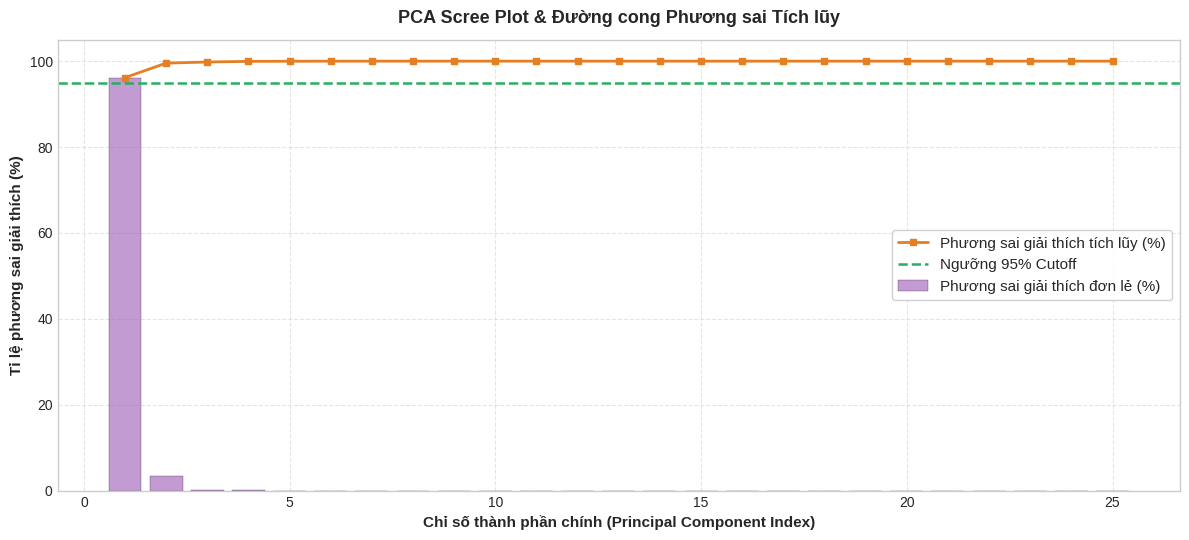

Đã lưu biểu đồ: plots/13_pca_explained_variance.png


In [12]:
# ==============================================================================
# Cell 11: Plot 13 - PCA Scree Plot & Phương sai Tích lũy
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 5.5))
comp_idx = range(1, len(cum_var) + 1)

ax.bar(comp_idx, exp_var * 100, color='#9b59b6', alpha=0.6, label='Phương sai giải thích đơn lẻ (%)', edgecolor='black', linewidth=0.3)
ax.plot(comp_idx, cum_var * 100, color='#e67e22', marker='s', markersize=4, linewidth=2, label='Phương sai giải thích tích lũy (%)')
ax.axhline(95, color='#27ae60', linestyle='--', linewidth=1.8, label='Ngưỡng 95% Cutoff')

ax.set_xlabel('Chỉ số thành phần chính (Principal Component Index)', fontsize=11, fontweight='bold')
ax.set_ylabel('Tỉ lệ phương sai giải thích (%)', fontsize=11, fontweight='bold')
ax.set_title('PCA Scree Plot & Đường cong Phương sai Tích lũy', fontsize=13, fontweight='bold', pad=12)
ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='center right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plots/13_pca_explained_variance.png', dpi=200, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ: plots/13_pca_explained_variance.png")

## Task 4.6: Lưu Trữ Deliverables & Chuẩn Bị Cho Phase 5 (Model Training)
Đóng gói tất cả các deliverables cần thiết:

In [13]:
# ==============================================================================
# Cell 12: Lưu Trữ Toàn Bộ Deliverables của Phase 4
# ==============================================================================
print("=" * 75)
print("LƯU TRỮ DELIVERABLES CỦA PHASE 4")
print("=" * 75)

# 1. Lưu tập đặc trưng đã rút gọn cho Train
joblib.dump(X_train_selected, 'data/X_train_selected.pkl', compress=3)
joblib.dump(X_train_selected, 'X_train_reduced.pkl', compress=3)
print("Đã lưu: data/X_train_selected.pkl & X_train_reduced.pkl")

# 2. Rút gọn đồng bộ cho tập Test (nếu có sẵn data/X_test.pkl)
for p_test in ['data/X_test.pkl', 'X_test.pkl']:
    if os.path.exists(p_test):
        try:
            X_test_raw = joblib.load(p_test)
            if hasattr(X_test_raw, 'columns'):
                avail_cols = [c for c in selected_features if c in X_test_raw.columns]
                X_test_sel = X_test_raw[avail_cols].copy()
                joblib.dump(X_test_sel, 'data/X_test_selected.pkl', compress=3)
                print(f"Đã đồng bộ rút gọn đặc trưng cho Test Set: data/X_test_selected.pkl ({X_test_sel.shape[1]} đặc trưng)")
            break
        except Exception as e:
            print(f"Lưu ý khi xử lý test set: {e}")

# 3. Lưu Metadata JSON
meta_export = {
    'total_original_features': int(X_train.shape[1]),
    'total_selected_features': len(selected_features),
    'selected_features': selected_features,
    'dropped_features': dropped_total_features,
    'dropped_variance_features': low_var_features,
    'dropped_correlation_features': dropped_corr_features,
    'cumulative_importance_captured': float(captured_importance),
    'pca_components_for_95_pct': k_95,
    'top_15_features': importance_df.head(15)[['rank', 'feature', 'consensus_importance']].to_dict(orient='records')
}
with open('models/selected_features.json', 'w', encoding='utf-8') as f:
    json.dump(meta_export, f, indent=4)
print("Đã lưu: models/selected_features.json")

# 4. Lưu Feature Selector Pipeline Artifacts
selector_artifact = {
    'selected_features': selected_features,
    'dropped_features': dropped_total_features,
    'importance_df': importance_df,
    'pca_model': pca
}
joblib.dump(selector_artifact, 'models/feature_selector.joblib')
joblib.dump(pca, 'models/pca_transformer.joblib')
print("Đã lưu: models/feature_selector.joblib & models/pca_transformer.joblib")

print("\n" + "=" * 75)
print("HOÀN THÀNH PHASE 4 THÀNH CÔNG! SẴN SÀNG CHO PHASE 5: MODEL TRAINING.")
print("=" * 75)

LƯU TRỮ DELIVERABLES CỦA PHASE 4
Đã lưu: data/X_train_selected.pkl & X_train_reduced.pkl
Đã lưu: models/selected_features.json
Đã lưu: models/feature_selector.joblib & models/pca_transformer.joblib

HOÀN THÀNH PHASE 4 THÀNH CÔNG! SẴN SÀNG CHO PHASE 5: MODEL TRAINING.
